# NB2 baseline : Accuracy, F1-score, F1-macro


---
## Section 1 — Installation & imports

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, cross_validate
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(' Imports OK')

 Imports OK


---
## Section 2 — Data Loading (filtered thematic dataset)
Le notebook utilise le CSV filtré cardio + diabète généré depuis NB1 (`full_data/claims_cardio_diabete_filtered.csv`).

In [2]:
from pathlib import Path

CSV_PATH = Path('mumin_claims_cardio_diabete_baseline_ready.csv')
if not CSV_PATH.exists():
    raise FileNotFoundError(
        'Filtered dataset not found: mumin_claims_cardio_diabete_baseline_ready.csv\n'
        'Run NB1 first to generate it.'
    )

raw_df = pd.read_csv(CSV_PATH, encoding='utf-8', low_memory=False)
print(f'All data loaded: {len(raw_df)} thematic claims')
print(f'CSV used: {CSV_PATH}')

All data loaded: 354 thematic claims
CSV used: mumin_claims_cardio_diabete_baseline_ready.csv


---
## Train / Test

In [3]:
X = raw_df['text'].values
y = raw_df['label'].values
print(f'Unique labels: {np.unique(y)}')
print(f'Class distribution: {Counter(y)}')


Unique labels: [0 1]
Class distribution: Counter({np.int64(0): 337, np.int64(1): 17})


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

In [5]:
train_count = pd.Series(y_train).value_counts()
test_count = pd.Series(y_test).value_counts()
print(f'Training set class distribution:\n{train_count}')
print(f'Test set class distribution:\n{test_count}')

Training set class distribution:
0    269
1     14
Name: count, dtype: int64
Test set class distribution:
0    68
1     3
Name: count, dtype: int64


---
## Section 4 — Construction of pipelines

### Paramètres TF-IDF 
| Paramètre | Valeur | Justification |
|---|---|---|
| `ngram_range` | (1, 2) | Capture les expressions bi-mot ('heart disease', 'clinical trial') |
| `max_features` | 10 000 | Limite le bruit tout en couvrant le vocabulaire médical |
| `sublinear_tf` | True | Compresse les fréquences élevées (log(1+tf)) — standard NLP |
| `stop_words` | english | Retire les mots vides non informatifs |
| `min_df` | 2 | Ignore les termes n'apparaissant qu'une seule fois |
| `max_df` | 0.95 | Ignore les termes présents dans >95% des docs |


In [6]:
TFIDF_PARAMS = dict(
    ngram_range=(1, 2),
    max_features=10000, 
    sublinear_tf=True,
    stop_words='english',
    min_df=2,
    max_df=0.95
)

pipeline_lr = Pipeline([
    ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
    ('clf', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced'))])


pipeline_nb = Pipeline([
    ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
    ('clf', MultinomialNB(alpha = 0.5))])

pipeline_svm = Pipeline([
    ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
    ('clf', LinearSVC(random_state=RANDOM_STATE, class_weight='balanced', C=1.0, max_iter=1000))])

In [7]:
model = {
    'logistic_regression': pipeline_lr,
    'naive_bayes': pipeline_nb,
    'LinearSVC': pipeline_svm
}

In [8]:
from sklearn.model_selection import cross_validate

min_class_count = pd.Series(y).value_counts().min()
n_splits = min(2, int(min_class_count))  # Ensure at least 2 splits, but not more than the smallest class count

SKF = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, pipe in model.items():
    print(f'Cross-validating {name}...')
    cv_results[name] = cross_validate(
        pipe,
        X,
        y,
        cv=SKF,
        scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'],
        return_train_score=False,
        n_jobs=-1
    )
    print(f'── {name} ──')
    print(f'  Accuracy  : {cv_results[name]["test_accuracy"].mean():.4f} ± {cv_results[name]["test_accuracy"].std():.4f}')
    print(f'  F1 macro  : {cv_results[name]["test_f1_macro"].mean():.4f} ± {cv_results[name]["test_f1_macro"].std():.4f}')
    print(f'  Precision : {cv_results[name]["test_precision_macro"].mean():.4f} ± {cv_results[name]["test_precision_macro"].std():.4f}')
    print(f'  Recall    : {cv_results[name]["test_recall_macro"].mean():.4f} ± {cv_results[name]["test_recall_macro"].std():.4f}')
    print()

Cross-validating logistic_regression...
── logistic_regression ──
  Accuracy  : 0.9379 ± 0.0113
  F1 macro  : 0.5941 ± 0.0466
  Precision : 0.6403 ± 0.0895
  Recall    : 0.5750 ± 0.0302

Cross-validating naive_bayes...
── naive_bayes ──
  Accuracy  : 0.9520 ± 0.0028
  F1 macro  : 0.4877 ± 0.0007
  Precision : 0.4760 ± 0.0014
  Recall    : 0.5000 ± 0.0000

Cross-validating LinearSVC...
── LinearSVC ──
  Accuracy  : 0.9520 ± 0.0028
  F1 macro  : 0.5710 ± 0.0840
  Precision : 0.6452 ± 0.1680
  Recall    : 0.5526 ± 0.0555



In [9]:
test_resuls = {}


for name, pipe in model.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    report_dict = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0,
    )
    per_class_f1 = {
        c: float(report_dict.get(c, {}).get('f1-score', 0.0))
        for c in [0, 1]
    }
    test_resuls[name] = {
        'y_pred': y_pred,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'recall': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'f1-macro': f1_score(y_test, y_pred, average='macro', zero_division=0),
        'per_class_f1': per_class_f1    
    }
    print(f'── {name} on test set ──')
    print(classification_report(
        y_test,
        y_pred,
        

        zero_division=0
    ))


── logistic_regression on test set ──
              precision    recall  f1-score   support

           0       0.97      0.94      0.96        68
           1       0.20      0.33      0.25         3

    accuracy                           0.92        71
   macro avg       0.58      0.64      0.60        71
weighted avg       0.94      0.92      0.93        71

── naive_bayes on test set ──
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        68
           1       0.00      0.00      0.00         3

    accuracy                           0.96        71
   macro avg       0.48      0.50      0.49        71
weighted avg       0.92      0.96      0.94        71

── LinearSVC on test set ──
              precision    recall  f1-score   support

           0       0.96      0.94      0.95        68
           1       0.00      0.00      0.00         3

    accuracy                           0.90        71
   macro avg       0.48      0.4

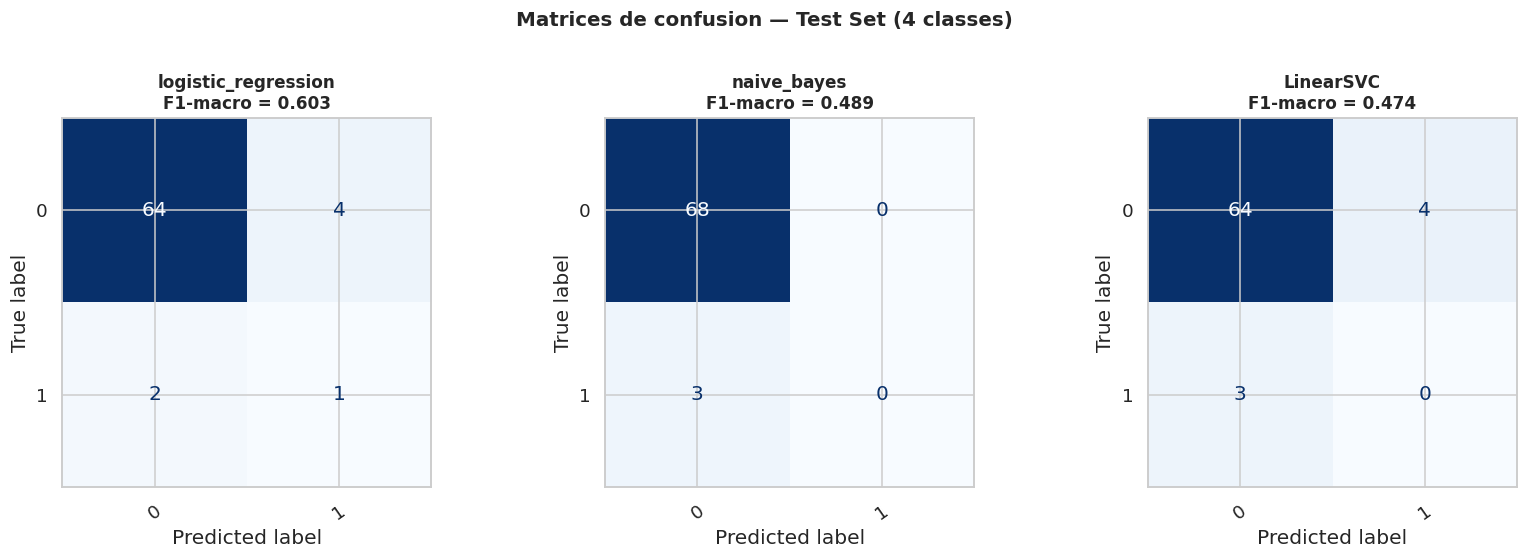

In [10]:
n_models = len(model)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4.8))
if n_models == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, test_resuls.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation=35)
    ax.set_title(f'{name}\nF1-macro = {res["f1-macro"]:.3f}', fontsize=11, fontweight='bold')

plt.suptitle('Matrices de confusion — Test Set (4 classes)', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

In [20]:
header = f'{"Modèle":<24} {"Acc":>7} {"Prec":>7} {"Recall":>7} {"F1-mac":>7} {"F1-w":>7} {"CV F1±σ":>13}'
print(header)
print('-' * 92)

for name, res in test_resuls.items():
    cv = cv_results[name]
    cv_f1_mean = cv['test_f1_macro'].mean()
    cv_f1_std = cv['test_f1_macro'].std()
    row = (
        f'{name:<24} '
        f'{res["accuracy"]:>7.3f} '
        f'{res["precision"]:>7.3f} '
        f'{res["recall"]:>7.3f} '
        f'{res["f1-macro"]:>7.3f} '
       
        f'{cv_f1_mean:>6.3f}±{cv_f1_std:.3f}'
    )
    print(row)

Modèle                       Acc    Prec  Recall  F1-mac    F1-w       CV F1±σ
--------------------------------------------------------------------------------------------
logistic_regression        0.915   0.585   0.637   0.603  0.594±0.047
naive_bayes                0.958   0.479   0.500   0.489  0.488±0.001
LinearSVC                  0.901   0.478   0.471   0.474  0.571±0.084
